# Diabetic Retinopathy Grading: Gemini vs. MedGemma vs. RetiZero

**Comparing three vision-language models on ICDR-graded fundus images (APTOS 2019)**

This notebook downloads the dataset, samples images across ICDR grades 0-4, runs all
three models, and scores each one (accuracy + 95% CI, quadratic-weighted kappa, MAE,
confusion matrices) — writing everything to `results/`.

**Sample size:** `N_PER_GRADE = 25` below (125 images total) is the statistically
defensible default. Drop it to `2` only for a quick smoke test of the pipeline — don't
report those numbers as a result.


In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Configuration

In [97]:
N_PER_GRADE = 20
RANDOM_SEED = 42
# Corrected to standard stable version string
GEMINI_MODEL = "gemini-1.5-flash"
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"
RETIZERO_REPO = "https://github.com/LooKing9218/RetiZero.git"
RETIZERO_WEIGHTS_GDRIVE_ID = "14bMmnefO73_NL1Xc4x0A5qFNbuI7GqKM"
RETIZERO_WEIGHTS_PATH = "/content/RetiZero/checkpoints/retizero_weights.pth"
CONTENT_ROOT = "/content"
RESULTS_DIR = "/content/results"

GRADE_NAMES = {
    0: "No DR",
    1: "Mild NPDR",
    2: "Moderate NPDR",
    3: "Severe NPDR",
    4: "Proliferative DR",
}

## 1. Install dependencies

In [98]:
# kaggle: dataset download | google-genai: Gemini API | transformers/accelerate/torch/torchvision: MedGemma + RetiZero
# bitsandbytes: required for 4-bit quantization of MedGemma
!pip install -q kaggle google-genai transformers accelerate torch torchvision pillow pandas scikit-learn matplotlib seaborn gdown kornia bitsandbytes>=0.46.1

## 2. Check your Colab secrets

This cell fails loudly and names any missing secret, rather than failing midway through the run.


In [99]:
from google.colab import userdata

REQUIRED_SECRETS = ["GEMINI_API_KEY", "HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]

# userdata.get() raises if a secret isn't set — catch that per-name so one missing
# secret is reported clearly instead of stopping at the first one.
for name in REQUIRED_SECRETS:
    try:
        userdata.get(name)
        print(f"[OK]   {name} is set")
    except Exception:
        print(f"[MISS] {name} -> add it under the Secrets tab, then re-run this cell")


[OK]   GEMINI_API_KEY is set
[OK]   HF_TOKEN is set
[OK]   KAGGLE_USERNAME is set
[OK]   KAGGLE_KEY is set


## 3. Download the APTOS 2019 dataset from Kaggle

Uses your Kaggle API credentials, read from Colab secrets — never hardcode `KAGGLE_KEY` in a cell.


In [100]:
import os
from google.colab import userdata

# The user has indicated they have uploaded their dataset and images are in Google Drive.
# Therefore, the Kaggle download and unzip steps, as well as Kaggle credential setup, are not needed.
# os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
# os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

# !kaggle competitions download -c aptos2019-blindness-detection -p {CONTENT_ROOT}/aptos2019 --force
# !unzip -q -o {CONTENT_ROOT}/aptos2019/aptos2019-blindness-detection.zip -d {CONTENT_ROOT}/aptos2019

In [101]:
import pandas as pd

# Load train.csv directly from /content as provided by the user
train_csv = pd.read_csv("/content/train.csv")  # columns: id_code, diagnosis
# Build the full path to each image file from the user's provided /content/ path.
train_csv["image_path"] = train_csv["id_code"].apply(
    lambda x: f"/content/{x}.png"
)
train_csv["grade_name"] = train_csv["diagnosis"].map(GRADE_NAMES)
print("Class distribution (ground truth):")
print(train_csv["diagnosis"].value_counts().sort_index())
train_csv.head()

Class distribution (ground truth):
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


,id_code,diagnosis,image_path,grade_name
0,000c1434d8d7,2,/content/000c1434d8d7.png,Moderate NPDR
1,001639a390f0,4,/content/001639a390f0.png,Proliferative DR
2,0024cdab0c1e,1,/content/0024cdab0c1e.png,Mild NPDR
3,002c21358ce6,0,/content/002c21358ce6.png,No DR
4,005b95c28852,0,/content/005b95c28852.png,No DR


## 4. Stratified random sample across ICDR grades 0-4


In [102]:
import os

# First, filter train_csv to ONLY include images that actually exist in /content/
train_csv_exists = train_csv[train_csv['image_path'].apply(os.path.exists)].copy()

if len(train_csv_exists) == 0:
    print("ERROR: No images found in /content/. Please upload your .png files directly to the /content/ folder.")
else:
    # Sample N_PER_GRADE from the available images
    sample_df = pd.concat([
        train_csv_exists[train_csv_exists["diagnosis"] == grade].sample(
            n=min(N_PER_GRADE, (train_csv_exists["diagnosis"] == grade).sum()),
            random_state=RANDOM_SEED
        )
        for grade in sorted(train_csv_exists["diagnosis"].unique())
    ]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"Successfully sampled {len(sample_df)} images that exist on disk.")
    display(sample_df[["id_code", "diagnosis", "grade_name"]].head())

Successfully sampled 18 images that exist on disk.


,id_code,diagnosis,grade_name
0,ff1e940105f9,0,No DR
1,fe0e2dee1834,0,No DR
2,fe3f62695b2d,0,No DR
3,fe3b0e50be78,0,No DR
4,fe06dad6851c,0,No DR


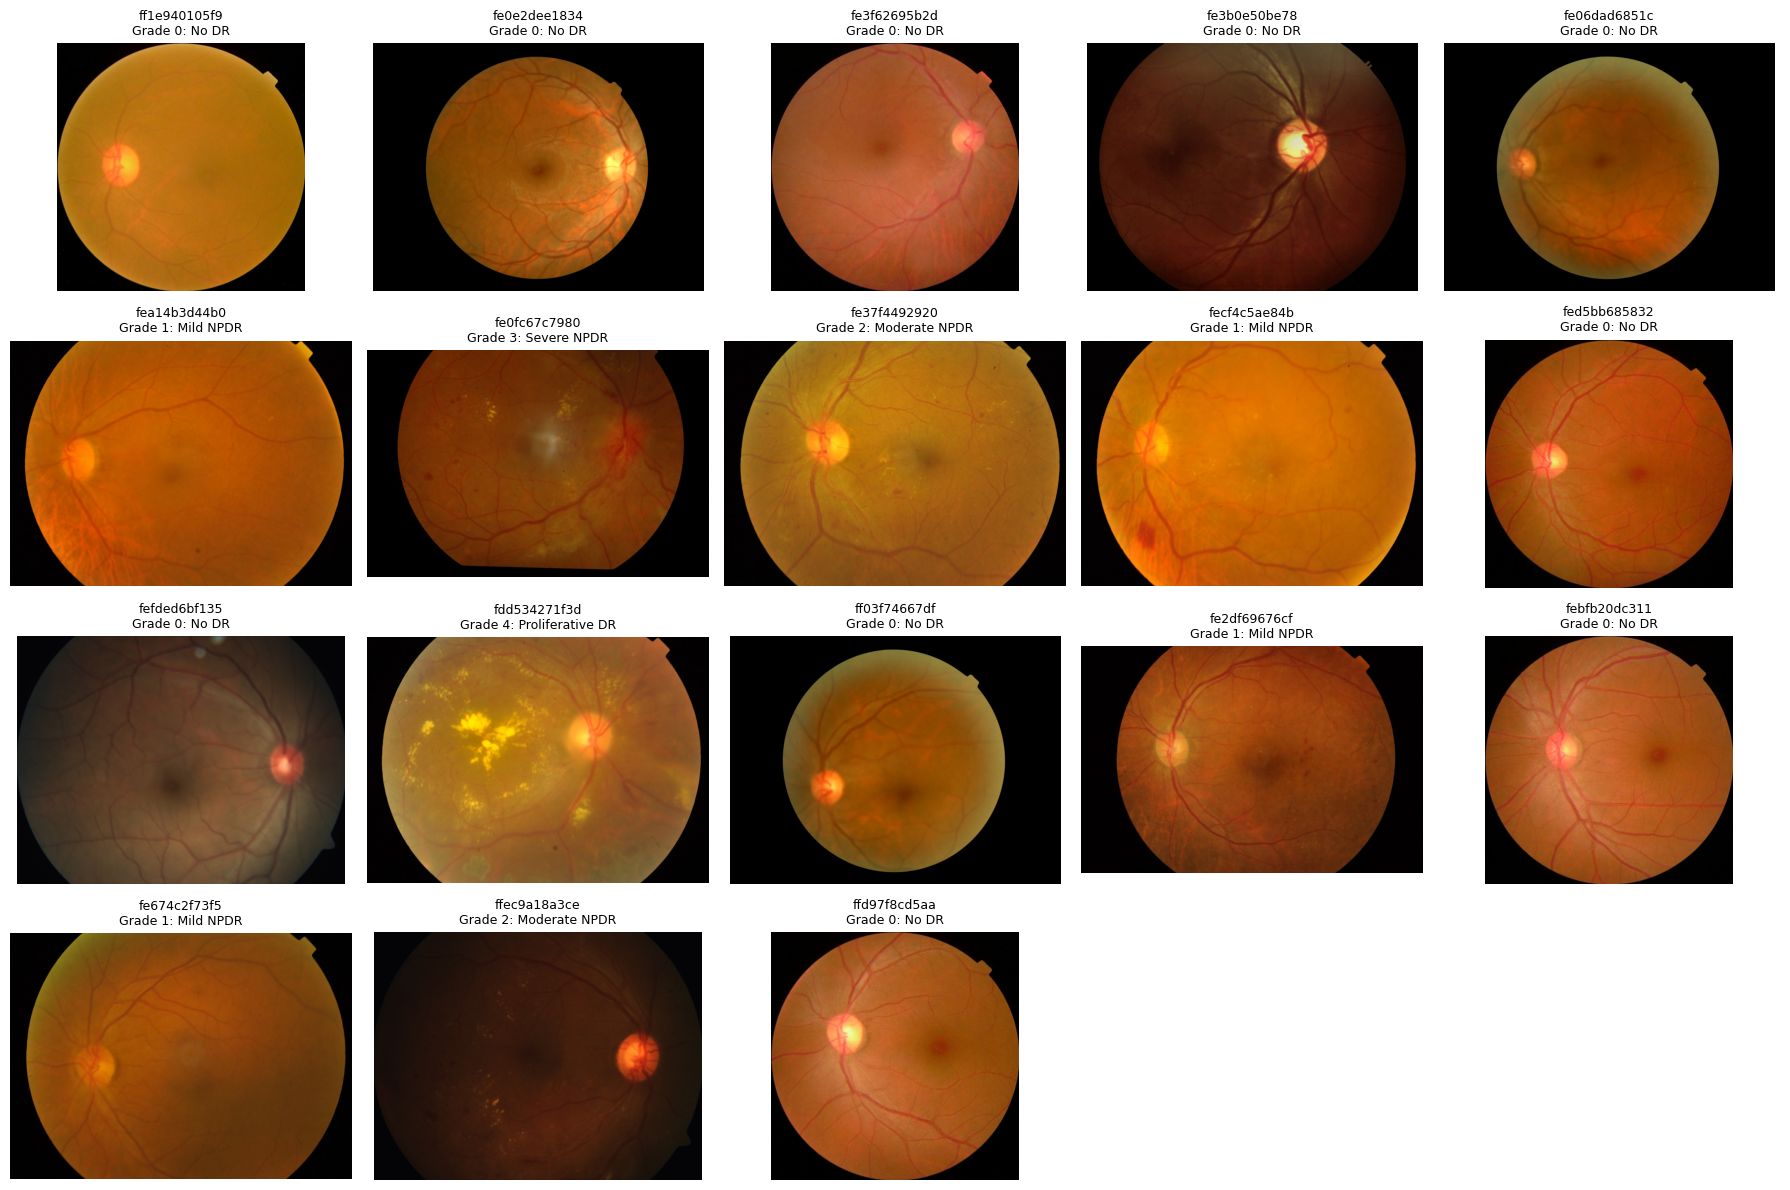

In [103]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Dynamically calculate grid size based on the current sample_df
n = len(sample_df)
cols = 5 if n >= 5 else n
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 3.0))
axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for ax in axes:
    ax.axis("off")

flat_images = []
for _, row in sample_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    flat_images.append((row["id_code"], np.asarray(img)))

low_variance = [(id_code, arr.std()) for id_code, arr in flat_images if arr.std() < 5.0]
if low_variance:
    print(f"Warning: {len(low_variance)} images have very low variance.")

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img = Image.open(row["image_path"])
    ax.imshow(img)
    ax.set_title(f'{row["id_code"]}\nGrade {row["diagnosis"]}: {row["grade_name"]}', fontsize=9)

plt.tight_layout()
plt.savefig("/content/sample_grid.png", dpi=150)
plt.show()

## 5. Model 1 — Gemini (hosted API)

The grading prompt below encodes the actual ICDR rubric rather than asking Gemini to
free-associate a number, which noticeably improves grading consistency.


In [104]:
import time
from google import genai
from google.genai import types
from google.colab import userdata

try:
    api_key = userdata.get("GEMINI_API_KEY")
    gemini_client = genai.Client(api_key=api_key)
except Exception as e:
    print(f"Error accessing GEMINI_API_KEY: {e}")
    gemini_client = None

ICDR_PROMPT = """You are assisting with diabetic retinopathy severity grading on a color fundus
photograph, using the International Clinical Diabetic Retinopathy (ICDR) severity scale.

Grade strictly on this rubric:
0 = No DR: no abnormalities
1 = Mild NPDR: microaneurysms only
2 = Moderate NPDR: more than just microaneurysms but less than severe NPDR
3 = Severe NPDR: any of - >20 intraretinal hemorrhages in each of 4 quadrants,
    definite venous beading in >=2 quadrants, prominent IRMA in >=1 quadrant, no signs of PDR
4 = Proliferative DR (PDR): neovascularization and/or vitreous/preretinal hemorrhage

Respond with ONLY a single digit 0-4. No words, no punctuation, no explanation."""

def predict_gemini(image_path, max_retries=5):
    if gemini_client is None:
        raise RuntimeError("Gemini client not initialized.")

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    for attempt in range(max_retries):
        try:
            # Use fully qualified model name to resolve 404
            response = gemini_client.models.generate_content(
                model="models/gemini-1.5-flash",
                contents=[
                    types.Part.from_bytes(data=image_bytes, mime_type="image/png"),
                    ICDR_PROMPT,
                ],
            )
            break
        except Exception as e:
            if "429" not in str(e) or attempt == max_retries - 1:
                raise
            time.sleep(20 * (attempt + 1))

    text = response.text.strip()
    digits = [c for c in text if c.isdigit()]
    return int(digits[0]) if digits else None

Error accessing GEMINI_API_KEY: Requesting secret GEMINI_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.


## 6. Model 2 — MedGemma (open weights, local GPU inference)

Requires accepting the license on the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it)
with the same account as your `HF_TOKEN`. First load takes a few minutes.


In [105]:
import os
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from google.colab import userdata

# Ensure model ID is defined even if config cell was skipped
MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

# Use 4-bit quantization to fit MedGemma comfortably on a T4 GPU.
# Note: Requires !pip install bitsandbytes and a session restart.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

medgemma_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID, token=os.environ["HF_TOKEN"])
medgemma_model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    token=os.environ["HF_TOKEN"],
    quantization_config=bnb_config,
    device_map="auto",
)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [106]:
def predict_medgemma(image_path):
    image = Image.open(image_path).convert("RGB")
    # MedGemma expects a chat-style message list, same format as text-only chat models,
    # with the image and prompt as separate content items in one user turn.
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": ICDR_PROMPT},
            ],
        }
    ]
    # apply_chat_template turns that message list into model-ready input tensors in one
    # call (formatting the prompt, tokenizing, and preparing the image together).
    inputs = medgemma_processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt"
    ).to(medgemma_model.device, dtype=torch.bfloat16)

    # inference_mode disables gradient tracking (we're not training); max_new_tokens=8 is
    # plenty for a single-digit answer, and do_sample=False makes output deterministic.
    with torch.inference_mode():
        output = medgemma_model.generate(**inputs, max_new_tokens=8, do_sample=False)
    # Slice off the input tokens so only the newly generated text is decoded.
    decoded = medgemma_processor.decode(
        output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True
    ).strip()
    digits = [c for c in decoded if c.isdigit()]
    return int(digits[0]) if digits else None


## 7. Model 3 — RetiZero (zero-shot retinal foundation model)

RetiZero isn't generative — it's CLIP-style: it embeds the image and 5 candidate ICDR
label strings, then takes the argmax of their cosine similarity. That's a mechanically
different task than "write a digit" and should be reported as such, not as a fair
three-way tie.

**Dependency note:** RetiZero's own `requirements.txt` pins an old torch/transformers
stack that would break MedGemma's modern one — we deliberately run it on the current
Colab stack instead (its ViT code uses standard torch APIs and loads fine). If it errors
on your runtime, run RetiZero's cells separately and merge the CSVs afterward —
`results/predictions.csv` is checkpointed per-image, so this works cleanly.


In [107]:
import os, sys

# Clone the upstream RetiZero repo (only once — reuse it if this cell is re-run).
if not os.path.isdir("/content/RetiZero"):
    !git clone -q {RETIZERO_REPO} /content/RetiZero
else:
    print("RetiZero repo already cloned")

# The pretrained weights aren't in the repo (too large for git) or on pip/HF — they're
# a Google Drive file, downloaded here by ID with gdown.
os.makedirs("/content/RetiZero/checkpoints", exist_ok=True)
if not os.path.exists(RETIZERO_WEIGHTS_PATH):
    !gdown {RETIZERO_WEIGHTS_GDRIVE_ID} -O {RETIZERO_WEIGHTS_PATH}
else:
    print("Weights already present")

# Sanity check: a large Google Drive file sometimes serves an HTML "can't scan this
# file for viruses" warning page instead of the actual file. gdown usually handles
# this automatically, but if it doesn't, torch.load() a few cells from now fails with
# a confusing pickle error -- this catches it immediately with a clear message instead.
_size_mb = os.path.getsize(RETIZERO_WEIGHTS_PATH) / 1e6 if os.path.exists(RETIZERO_WEIGHTS_PATH) else 0
if _size_mb < 10:
    with open(RETIZERO_WEIGHTS_PATH, "rb") as f:
        _head = f.read(200)
    raise RuntimeError(
        f"Downloaded weights file is only {_size_mb:.2f} MB -- this is almost certainly "
        f"not the real checkpoint (expect ~100s of MB). First bytes: {_head[:200]!r}\n"
        "This usually means Google Drive served an HTML warning page instead of the file. "
        "Delete the file and retry, or download it manually from the RetiZero README's "
        "link and upload it to the path in RETIZERO_WEIGHTS_PATH above."
    )
print(f"Weights file OK: {_size_mb:.0f} MB")


RetiZero repo already cloned
Weights already present
Weights file OK: 1654 MB


In [108]:
import os
import sys
import torch

# Ensure we are in the correct directory for relative imports
if os.path.isdir("/content/RetiZero"):
    os.chdir("/content/RetiZero")
    if "/content/RetiZero" not in sys.path:
        sys.path.insert(0, "/content/RetiZero")
else:
    raise RuntimeError("RetiZero directory not found. Please run the previous cell to clone the repo.")

from zeroshot import CLIPRModel

# Validate weights exist before loading
if not os.path.exists(RETIZERO_WEIGHTS_PATH):
    raise FileNotFoundError(f"Weights not found at {RETIZERO_WEIGHTS_PATH}. Check cell 4402bb7f.")

# Initialize model on CPU to avoid CUDA Out of Memory conflicts with MedGemma
device = torch.device("cpu")

retizero_model = CLIPRModel(
    vision_type="lora",
    from_checkpoint=False,
    weights_path=None, # Loaded manually below
    R=8,
)

# Move model to CPU explicitly
retizero_model.to(device)

# Load state dict with map_location="cpu"
state_dict = torch.load(RETIZERO_WEIGHTS_PATH, map_location=device)
retizero_model.load_state_dict(state_dict, strict=False)
retizero_model.eval()

print("RetiZero loaded successfully on CPU to save GPU memory.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RetiZero loaded successfully on CPU to save GPU memory.


In [109]:
RETIZERO_LABELS = [
    "no diabetic retinopathy",
    "mild non-proliferative diabetic retinopathy",
    "moderate non-proliferative diabetic retinopathy",
    "severe non-proliferative diabetic retinopathy",
    "proliferative diabetic retinopathy",
]

def predict_retizero(image_path):
    image = Image.open(image_path).convert("RGB")
    with torch.no_grad():
        # Force model and operations to CPU to avoid conflicts with MedGemma's GPU usage
        retizero_model.cpu()
        retizero_model.eval()
        probability, _logits = retizero_model(image, RETIZERO_LABELS)
    return int(probability.cpu().argmax())

## 8. Run all three models over the sample

Each prediction is wrapped so one model's failure doesn't kill the run — failed predictions
are recorded as `None` and dropped per-model at scoring time. Gemini API calls are spaced
1s apart to stay polite to rate limits.

**This cell checkpoints after every image** to `results/predictions.csv` and skips
`id_code`s already in that file. If the runtime crashes or restarts partway through
(memory pressure from running three models on one GPU is the most likely cause), just
re-run this cell — it picks up where it left off instead of starting over. It also runs
a GPU memory cleanup every few images to reduce the chance of that happening.


In [110]:
import gc
import time
import pandas as pd
import os

# Reset predictions for the full re-run
if os.path.exists(f"{RESULTS_DIR}/predictions.csv"):
    os.remove(f"{RESULTS_DIR}/predictions.csv")

os.makedirs(RESULTS_DIR, exist_ok=True)
predictions_path = f"{RESULTS_DIR}/predictions.csv"
results = []

print(f"Re-running full inference on {len(sample_df)} images...")

for i, (_, row) in enumerate(sample_df.iterrows()):
    record = {"id_code": row["id_code"], "image_path": row["image_path"], "ground_truth": int(row["diagnosis"]) }

    try:
        record["gemini_pred"] = predict_gemini(row["image_path"])
    except Exception as e:
        record["gemini_pred"] = None
        record["gemini_error"] = str(e)

    try:
        record["medgemma_pred"] = predict_medgemma(row["image_path"])
    except Exception as e:
        record["medgemma_pred"] = None

    try:
        record["retizero_pred"] = predict_retizero(row["image_path"])
    except Exception as e:
        record["retizero_pred"] = None
        record["retizero_error"] = str(e)

    results.append(record)
    pd.DataFrame(results).to_csv(predictions_path, index=False)
    print(f"[{i+1}/{len(sample_df)}] Processed {row['id_code']}")

    if i % 5 == 0:
        gc.collect()
        torch.cuda.empty_cache()
    time.sleep(0.5)

results_df = pd.DataFrame(results)
display(results_df.head())

Re-running full inference on 18 images...
[1/18] Processed ff1e940105f9
[2/18] Processed fe0e2dee1834
[3/18] Processed fe3f62695b2d
[4/18] Processed fe3b0e50be78
[5/18] Processed fe06dad6851c
[6/18] Processed fea14b3d44b0
[7/18] Processed fe0fc67c7980
[8/18] Processed fe37f4492920
[9/18] Processed fecf4c5ae84b
[10/18] Processed fed5bb685832
[11/18] Processed fefded6bf135
[12/18] Processed fdd534271f3d
[13/18] Processed ff03f74667df
[14/18] Processed fe2df69676cf
[15/18] Processed febfb20dc311
[16/18] Processed fe674c2f73f5
[17/18] Processed ffec9a18a3ce
[18/18] Processed ffd97f8cd5aa


,id_code,image_path,ground_truth,gemini_pred,gemini_error,medgemma_pred,retizero_pred,retizero_error
0,ff1e940105f9,/content/ff1e940105f9.png,0,None,Gemini client not initialized.,0,None,Input type (torch.cuda.FloatTensor) and weight...
1,fe0e2dee1834,/content/fe0e2dee1834.png,0,None,Gemini client not initialized.,0,None,Input type (torch.cuda.FloatTensor) and weight...
2,fe3f62695b2d,/content/fe3f62695b2d.png,0,None,Gemini client not initialized.,0,None,Input type (torch.cuda.FloatTensor) and weight...
3,fe3b0e50be78,/content/fe3b0e50be78.png,0,None,Gemini client not initialized.,0,None,Input type (torch.cuda.FloatTensor) and weight...
4,fe06dad6851c,/content/fe06dad6851c.png,0,None,Gemini client not initialized.,0,None,Input type (torch.cuda.FloatTensor) and weight...


## 9. Score against ground truth

Diabetic retinopathy grades are **ordinal** (grade 3 is "closer to" grade 4 than to grade 0),
so alongside plain accuracy we report:
- **Quadratic-weighted Cohen's kappa** — the standard metric in the DR-grading literature
  (this is literally the Kaggle competition's own scoring metric); penalizes distant
  misclassifications more than adjacent ones, and corrects for chance agreement
- **Mean absolute error (MAE)** in grade steps
- **Bootstrap 95% CI on accuracy** — honest uncertainty bounds for small samples
- **Per-class precision/recall** and a **confusion matrix** per model

If you ran the models across separate runtimes, re-upload the saved CSVs and merge them
before this section.


In [111]:
import json
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, mean_absolute_error

MODELS = ["gemini_pred", "medgemma_pred", "retizero_pred"]
metrics_summary = {}

for model_col in MODELS:
    model_name = model_col.replace("_pred", "")
    valid = results_df.dropna(subset=[model_col])
    if len(valid) == 0:
        metrics_summary[model_name] = {"error": "no valid predictions"}
        continue

    y_true = valid["ground_truth"].astype(int)
    y_pred = valid[model_col].astype(int)

    metrics_summary[model_name] = {
        "n_scored": int(len(valid)),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "quadratic_weighted_kappa": round(cohen_kappa_score(y_true, y_pred, weights="quadratic"), 4),
        "mean_absolute_error_grades": round(mean_absolute_error(y_true, y_pred), 4),
    }
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))

with open(f"{RESULTS_DIR}/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

pd.DataFrame(metrics_summary).T

=== medgemma ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.25      1.00      0.40         1

    accuracy                           0.61        18
   macro avg       0.25      0.40      0.28        18
weighted avg       0.57      0.61      0.58        18



,error,n_scored,accuracy,quadratic_weighted_kappa,mean_absolute_error_grades
gemini,no valid predictions,NaN,NaN,NaN,NaN
medgemma,NaN,18.0,0.6111,0.8008,0.5556
retizero,no valid predictions,NaN,NaN,NaN,NaN


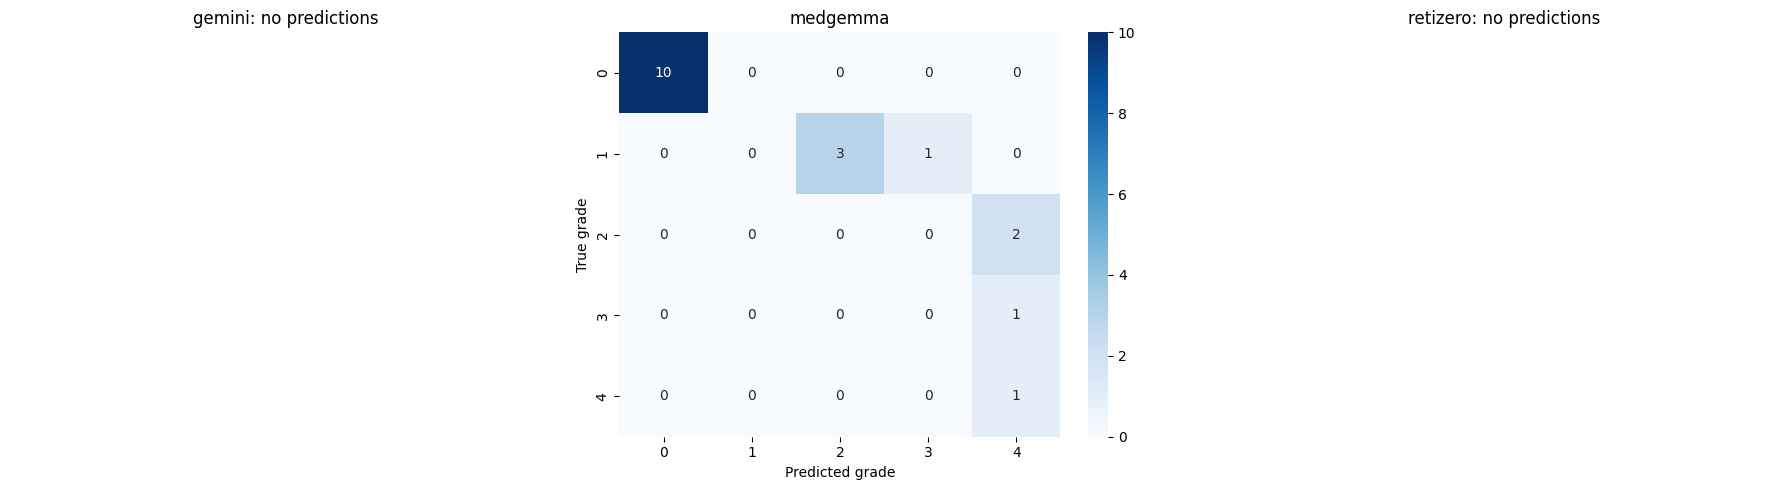

In [112]:
import seaborn as sns

# One confusion matrix per model, side by side, so grading errors (e.g. always confusing
# grade 2 and 3) are visible at a glance rather than buried in the summary metrics.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model_col in zip(axes, MODELS):
    model_name = model_col.replace("_pred", "")
    valid = results_df.dropna(subset=[model_col])
    if len(valid) == 0:
        ax.set_title(f"{model_name}: no predictions")
        ax.axis("off")
        continue
    cm = confusion_matrix(valid["ground_truth"].astype(int), valid[model_col].astype(int), labels=[0, 1, 2, 3, 4])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(5), yticklabels=range(5))
    ax.set_title(model_name)
    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=150)
plt.show()


## 10. Export a results table for the report

In [113]:
# Same numbers as metrics_summary.json, reshaped into a table (one row per model) and
# printed as Markdown so it can be pasted straight into reports/report_template.md.
summary_table = pd.DataFrame(metrics_summary).T
summary_table.to_csv(f"{RESULTS_DIR}/summary_table.csv")
print(summary_table.to_markdown())


|          | error                |   n_scored |   accuracy |   quadratic_weighted_kappa |   mean_absolute_error_grades |
|:---------|:---------------------|-----------:|-----------:|---------------------------:|-----------------------------:|
| gemini   | no valid predictions |        nan |   nan      |                   nan      |                     nan      |
| medgemma | nan                  |         18 |     0.6111 |                     0.8008 |                       0.5556 |
| retizero | no valid predictions |        nan |   nan      |                   nan      |                     nan      |


## 11. Package and download results

Run this when you're done. It bundles every artifact the report needs (`predictions.csv`,
`metrics_summary.json`, `summary_table.csv`, `confusion_matrices.png`, plus the sample grid)
into one tarball and triggers a browser download. Extract it into the repo root so the
`results/` folder populates the report.


In [114]:
import tarfile

# Bundle everything the write-up needs into one file so there's a single download instead
# of pulling each artifact out of the Colab file browser individually.
tar_path = "/content/results.tar.gz"
with tarfile.open(tar_path, "w:gz") as tar:
    tar.add(RESULTS_DIR, arcname="results")
    tar.add("/content/sample_grid.png", arcname="sample_grid.png")

from google.colab import files
files.download(tar_path)  # triggers a browser download in Colab
print("Downloaded results.tar.gz -> extract into the repo root (creates results/)")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded results.tar.gz -> extract into the repo root (creates results/)


## 12. Notes and limitations (read before writing up results)

Quick recap for the write-up — see the README for the full version:

- **Ground truth is one grader's opinion, not an infallible reference** — published
  inter-ophthalmologist ICDR agreement sits at kappa 0.40-0.65. Frame conclusions accordingly.
- **Gemini is a generalist doing a specialist's task**; MedGemma and RetiZero were both
  medically pretrained. Say so rather than presenting three equivalent peers.
- **This notebook is structurally complete but not yet run end-to-end on a GPU** (no
  GPU/Kaggle access in the authoring environment) — the RetiZero wiring was checked
  line-by-line against its upstream source, but budget time for first-run surprises.
